# Confidence-interval estimator test suite

Minimal evaluation harness for an online interval estimator on a **single-feature LMS testbed**.
While a feature is learned online, an estimator maintains an interval `[lcb, ucb]` for that
feature's potential utility `U* = E[ |theta* * phi| ]`. For the clean single feature here
(`phi = x ~ Uniform(-1, 1)`, optimum reconstructs the signal) this is known in closed form:

`U* = E[ |w * x| ] = |w| * E[|x|] = |w| / 2`  (noise-independent; computed analytically, never shown to the estimator).

Style mirrors the rest of this folder: JAX with `vmap` over seeds and `lax.scan` over steps, and
several pluggable interval estimators. Four are wired up below: the **placeholder** from the spec
(plumbing only), the correlation-based **Fable** empirical-Bernstein interval, the **Analytical** ratio CI, and **Hybrid** (unbiased + conservative, 4 scalars/feature). Run top to bottom.

In [1]:
# --- imports and shared defaults (spec Section 7) ---
from functools import partial
from typing import NamedTuple
import json
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import t as t_dist
import equinox as eqx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd.jax_core.utils import tree_replace

ALPHA = 0.1          # LMS step-size (constant; no decay, no warmup)
N_SEEDS = 100         # independent data streams
Z = 1.96             # 95% normal quantile
EPS = 1e-8
EX_ABS = 0.5         # E|x| for x ~ Uniform(-1, 1), so U* = |w| * E|x| = |w| / 2

OUT_DIR = Path('data/ci_suite')
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('JAX device:', jax.devices()[0])

JAX device: cuda:0


In [2]:
# --- testbed configuration + the per-step observation handed to estimators (spec Section 4-5) ---
# target_weight(t) is the only thing that differs across experiments: constant for Exp 1-3
# (onset = 0, so w_after holds from t = 0), and a 0 -> w step at t = onset for Exp 4.

class Config(NamedTuple):
    alpha: jax.Array
    sigma: jax.Array
    w_before: jax.Array
    w_after: jax.Array
    onset: jax.Array

def make_config(sigma, w, alpha=ALPHA, onset=0, w_before=None):
    w_before = w if w_before is None else w_before
    return Config(jnp.asarray(alpha, float), jnp.asarray(sigma, float),
                  jnp.asarray(w_before, float), jnp.asarray(w, float),
                  jnp.asarray(onset, jnp.int32))

class StepObservation(NamedTuple):
    t: jax.Array          # step index
    phi: jax.Array        # feature value this step
    theta: jax.Array      # learner weight used to predict (pre-update)
    y_hat: jax.Array      # prediction
    y: jax.Array          # target
    residual: jax.Array   # y - y_hat

def target_weight(steps, cfg_py):
    # numpy ground-truth weight at the given steps; cfg_py is a plain dict (evaluation only).
    steps = np.asarray(steps)
    return np.where(steps < cfg_py['onset'], cfg_py['w_before'], cfg_py['w_after'])

def u_star(steps, cfg_py):
    return np.abs(target_weight(steps, cfg_py)) * EX_ABS

In [11]:
# --- pluggable interval estimators (spec Section 5) ---
# Each is an eqx.Module with: init() -> fresh state; update(obs) -> new state (every step);
# bounds() -> (lcb, ucb) for U* with lcb >= 0 (read at logged steps). Add a method by writing
# such a class and appending (name, cls) to ESTIMATORS. The estimator never sees w, sigma, or U*.

class Placeholder(eqx.Module):
    # PLACEHOLDER, plumbing only (spec Section 5). Fixed-n EMA mean/variance of the realized
    # contribution |theta*phi|, with a normal CI of half-width z*sqrt(var/n_eff), n_eff = 1/(1-decay).
    # Not a method we trust; it just lets the harness and plots run before real estimators go in.
    decay: float = eqx.field(static=True)
    z: float = eqx.field(static=True)
    mean: jax.Array
    var: jax.Array

    @classmethod
    def init(cls, decay=0.999, z=Z):
        return cls(decay=decay, z=z, mean=jnp.array(0.0), var=jnp.array(0.0))

    def update(self, obs):
        g = jnp.abs(obs.theta * obs.phi)
        d = self.decay
        mean = d * self.mean + (1.0 - d) * g
        var = d * self.var + (1.0 - d) * (g - mean) ** 2
        return tree_replace(self, mean=mean, var=var)

    def bounds(self):
        n_eff = 1.0 / (1.0 - self.decay)
        half = self.z * jnp.sqrt(self.var / n_eff)
        return jnp.maximum(0.0, self.mean - half), self.mean + half


class Fable(eqx.Module):
    # Correlation-based empirical-Bernstein interval (adapted from fable_method.py). Rather than
    # bounding the CURRENT contribution, it bounds the optimal weight implied by the feature's
    # correlation with the residual, so it predicts U* before theta has finished climbing. With
    # g = ema(e*phi) and m = ema(phi^2), the self-excluded correlation a = g + theta*m has
    # least-squares optimum theta* = a/m. An empirical-Bernstein se on a gives [a-se, a+se];
    # pushing that through /m bounds |theta*|, and times xbar = ema(|phi|) maps to U* = E|theta* * phi|.
    lam: float = eqx.field(static=True)
    z: float = eqx.field(static=True)
    eps: float = eqx.field(static=True)
    g: jax.Array        # ema(e*phi)   feature-residual correlation
    m: jax.Array        # ema(phi^2)
    q: jax.Array        # ema((e*phi)^2)
    e2: jax.Array       # ema(e^2)     residual scale for the EB range term
    xbar: jax.Array     # ema(|phi|)   maps the optimal weight to L1 utility
    b: jax.Array        # debias factor 1 - (1-lam)^t
    age: jax.Array
    w: jax.Array        # latest learner weight (theta), to un-exclude self in a

    @classmethod
    def init(cls, lam=0.0001, z=Z, eps=EPS):
        zero = jnp.array(0.0)
        return cls(lam=lam, z=z, eps=eps, g=zero, m=zero, q=zero, e2=zero,
                   xbar=zero, b=zero, age=zero, w=zero)

    def update(self, obs):
        lam = self.lam
        ex = obs.residual * obs.phi
        b = (1.0 - lam) * self.b + lam
        g = (1.0 - lam) * self.g + lam * ex
        m = (1.0 - lam) * self.m + lam * (obs.phi * obs.phi)
        q = (1.0 - lam) * self.q + lam * (ex * ex)
        e2 = (1.0 - lam) * self.e2 + lam * (obs.residual * obs.residual)
        xbar = (1.0 - lam) * self.xbar + lam * jnp.abs(obs.phi)
        return tree_replace(self, g=g, m=m, q=q, e2=e2, xbar=xbar, b=b,
                            age=self.age + 1.0, w=obs.theta)

    def bounds(self):
        g_hat, m_hat, q_hat = self.g / self.b, self.m / self.b, self.q / self.b
        e2_hat, xbar_hat = self.e2 / self.b, self.xbar / self.b
        a = g_hat + self.w * m_hat                       # self-excluded correlation -> theta* = a/m
        n_eff = jnp.minimum(self.age, 2.0 / self.lam)
        V = jnp.maximum(q_hat - g_hat * g_hat, 0.0) * n_eff / jnp.maximum(n_eff - 1.0, 1.0)
        se = self.z * (jnp.sqrt(V / n_eff) + 3.0 * jnp.sqrt(e2_hat * m_hat) / n_eff)
        inv_m = 1.0 / (m_hat + self.eps)
        lo_a, hi_a = a - se, a + se
        w_hi = jnp.maximum(jnp.abs(lo_a), jnp.abs(hi_a)) * inv_m
        w_lo = jnp.where(lo_a * hi_a > 0.0,
                         jnp.minimum(jnp.abs(lo_a), jnp.abs(hi_a)), 0.0) * inv_m
        return w_lo * xbar_hat, w_hi * xbar_hat
    
    
class Analytical(eqx.Module):
    lam: float = eqx.field(static=True)
    z: float = eqx.field(static=True)
    eps: float = eqx.field(static=True)
    xbar: jax.Array
    age: jax.Array
    w: jax.Array        # latest learner weight (theta), to un-exclude self in a
    
    x: jax.Array # trace of x_i * residual_i
    y: jax.Array # trace of x_i^2
    xy: jax.Array # trace of x_i * x_i * residual_i
    x2: jax.Array # trace of x_i^2 * residual_i
    y2: jax.Array # trace of x_i^4

    @classmethod
    def init(cls, lam=0.9999, z=Z, eps=EPS):
        zero = jnp.array(0.0)
        return cls(lam=lam, z=z, eps=eps, age=zero, w=zero, xbar=zero,
                   x=zero, y=zero, xy=zero, x2=zero, y2=zero)

    def update(self, obs):
        # Keeping trace of values to compute the optimal weight
        # w* = sum(x_i * residual_i) / sum(x_i^2), where residual_i is the residual without considering the feature
        # The residual correlation is x_i * residual_i, and the feature variance is x_i^2
        independent_residual = obs.residual + obs.phi * obs.theta # Residual not considering the feature (in this case this is just the target, y)
        residual_correlation = independent_residual * obs.phi
        feature_variance = obs.phi * obs.phi
        
        lam = self.lam
        rlam = 1.0 - lam
        xi = residual_correlation
        yi = feature_variance
        
        x = lam * self.x + rlam * xi
        y = lam * self.y + rlam * yi
        xy = lam * self.xy + rlam * xi * yi
        x2 = lam * self.x2 + rlam * xi * xi
        y2 = lam * self.y2 + rlam * yi * yi
        
        xbar = lam * self.xbar + rlam * jnp.abs(obs.phi)
        
        new_state = tree_replace(
            self,
            x=x,
            y=y,
            xy=xy,
            x2=x2,
            y2=y2,
            xbar=xbar,
            w=obs.theta,
            age=self.age + 1.0,
        )
        
        ######################
        
        return new_state

    def bounds(self):
        lam = self.lam
        rlam = 1.0 - lam
        
        c = 1.0 - lam ** self.age # bias correction
        n_eff = (c * (1.0 + lam)) / (rlam * (2.0 - c) + self.eps) # effective sample size
        
        x_c = self.x / c
        y_c = self.y / c
        xy_c = self.xy / c
        x2_c = self.x2 / c
        y2_c = self.y2 / c
        
        xbar_c = self.xbar / c
        
        optimal_weight = x_c / y_c
        
        sigma_xx = x2_c - x_c * x_c
        sigma_yy = y2_c - y_c * y_c
        sigma_xy = xy_c - x_c * y_c
        
        sigma2 = sigma_xx - 2.0 * optimal_weight * sigma_xy + optimal_weight * optimal_weight * sigma_yy
        variance = sigma2 / ((n_eff - 1.0) * y_c * y_c + self.eps)
        
        # get the t statistic for a 95% CI in jax
        z_stat = 1.96 # Should really use the t-statistic
        bound = z_stat * jnp.sqrt(variance)
        w_low = optimal_weight - bound
        w_high = optimal_weight + bound
        
        a, b = jnp.abs(w_low), jnp.abs(w_high)
        straddles = (w_low <= 0.0) & (w_high >= 0.0)
        util_high = jnp.maximum(a, b) * xbar_c
        util_low  = jnp.where(straddles, 0.0, jnp.minimum(a, b)) * xbar_c
        
        return util_low, util_high



class Hybrid(eqx.Module):
    # Proposed estimator: Fable's conservatism with Analytical2's unbiasedness, at a smaller footprint
    # (4 scalars/feature, no global state, 3 EMAs/step). Two ideas:
    #  (1) Unbiased centre from the per-step partial residual pr = e + theta*phi (= y, single feature):
    #      a = ema(pr*phi) tracks ema(y*phi) with no dependence on the current weight, so there is none
    #      of Fable's drift bias (it never reconstructs a = g + theta_now*m).
    #  (2) Cheap, conservative width from the LMS residual: V = ema((e*phi)^2). Because e already has the
    #      signal subtracted, Var(e*phi) ~ Var(phi*r) is the small regression-residual variance directly
    #      (no delta method / no phi^4 moments). While theta is still climbing e > r, so V is auto-inflated
    #      -> wider when young. Bound a, map to w* = a/m, then to L1 utility via xbar = ema(|phi|).
    # For a production pruner: drop xbar and report L2 utility a^2/m (3 scalars + age) -- same ranking.
    lam: float = eqx.field(static=True)      # EMA update rate; memory ~ 1/lam steps
    beta: float = eqx.field(static=True)     # width multiplier (raise above ~2 for extra conservatism)
    kappa: float = eqx.field(static=True)    # range-term weight; keeps young features wide
    eps: float = eqx.field(static=True)
    a: jax.Array        # ema(pr*phi)     unbiased correlation -> w* = a/m
    m: jax.Array        # ema(phi^2)
    q: jax.Array        # ema((e*phi)^2)  conservative variance scale (uses the LMS residual)
    xbar: jax.Array     # ema(|phi|)      maps |w*| to L1 utility
    age: jax.Array

    @classmethod
    def init(cls, lam=0.0001, beta=1.96, kappa=0.0, eps=EPS):
        zero = jnp.array(0.0)
        return cls(lam=lam, beta=beta, kappa=kappa, eps=eps,
                   a=zero, m=zero, q=zero, xbar=zero, age=zero)

    def update(self, obs):
        lam = self.lam
        pr = obs.residual + obs.theta * obs.phi          # partial residual incl. self (= y here)
        ex = obs.residual * obs.phi                      # LMS residual x feature -> variance scale
        return tree_replace(self,
            a=(1.0 - lam) * self.a + lam * (pr * obs.phi),
            m=(1.0 - lam) * self.m + lam * (obs.phi * obs.phi),
            q=(1.0 - lam) * self.q + lam * (ex * ex),
            xbar=(1.0 - lam) * self.xbar + lam * jnp.abs(obs.phi),
            age=self.age + 1.0)

    def bounds(self):
        lam = self.lam
        c = 1.0 - (1.0 - lam) ** self.age                # debias factor (= Kish c)
        a_hat, m_hat, q_hat, xbar_hat = self.a / c, self.m / c, self.q / c, self.xbar / c
        n_eff = (c * (2.0 - lam)) / (lam * (2.0 - c) + self.eps)   # Kish effective sample size
        V = q_hat                                        # conservative: drops -g^2; e >= true residual early
        se = self.beta * (jnp.sqrt(V / n_eff) + self.kappa * jnp.sqrt(V) / n_eff)
        lo_a, hi_a = a_hat - se, a_hat + se
        inv_m = 1.0 / (m_hat + self.eps)
        w_hi = jnp.maximum(jnp.abs(lo_a), jnp.abs(hi_a)) * inv_m
        w_lo = jnp.where(lo_a * hi_a > 0.0,
                         jnp.minimum(jnp.abs(lo_a), jnp.abs(hi_a)), 0.0) * inv_m
        return w_lo * xbar_hat, w_hi * xbar_hat


ESTIMATORS = [('Placeholder', Placeholder), ('Fable', Fable), ('Analytical', Analytical), ('Hybrid', Hybrid)]
METHOD_COLORS = {'Placeholder': 'tab:gray', 'Fable': 'tab:blue', 'Analytical': 'tab:red', 'Hybrid': 'tab:green'}

In [12]:
# --- harness: vmap over seeds, scan over steps; every estimator advanced at once (spec Section 4) ---

def _step_obs(t, x, theta, y):
    y_hat = theta * x
    return StepObservation(t=t, phi=x, theta=theta, y_hat=y_hat, y=y, residual=y - y_hat)

def _run_seed(key, cfg, T):
    # one data stream + one learner; LMS update applied AFTER building the observation.
    ests0 = tuple(cls.init() for _, cls in ESTIMATORS)
    def body(carry, _):
        key, t, theta, ests = carry
        key, kx, ke = jr.split(key, 3)
        x = jr.uniform(kx, (), minval=-1.0, maxval=1.0)
        eps = cfg.sigma * jr.normal(ke)
        w_t = jnp.where(t < cfg.onset, cfg.w_before, cfg.w_after)
        y = w_t * x + eps
        obs = _step_obs(t, x, theta, y)
        new_ests, lcbs, ucbs = [], [], []
        for st in ests:
            st = st.update(obs)
            lcb, ucb = st.bounds()
            new_ests.append(st); lcbs.append(lcb); ucbs.append(ucb)
        theta = theta + cfg.alpha * obs.residual * x
        return (key, t + 1, theta, tuple(new_ests)), (jnp.stack(lcbs), jnp.stack(ucbs))
    init = (key, jnp.array(0, jnp.int32), jnp.array(0.0), ests0)
    _, (lcb, ucb) = jax.lax.scan(body, init, xs=None, length=T)
    return lcb, ucb                                       # (T, n_methods) each

@partial(jax.jit, static_argnames=('T',))
def _run_experiment(keys, cfg, log_steps, T):
    lcb, ucb = jax.vmap(lambda k: _run_seed(k, cfg, T))(keys)   # (n_seeds, T, n_methods)
    return lcb[:, log_steps], ucb[:, log_steps]                 # (n_seeds, n_log, n_methods)

def run(cfg, log_steps, T, n_seeds=N_SEEDS, seed=0):
    keys = jr.split(jr.PRNGKey(seed), n_seeds)
    lcb, ucb = _run_experiment(keys, cfg, jnp.asarray(log_steps), int(T))
    return np.asarray(lcb), np.asarray(ucb)               # (n_seeds, n_log, n_methods)

def build_log_steps(T, extra=(), n=200):
    # ~n log-spaced steps (denser early), always including 0 and T-1, plus any `extra` steps.
    s = set((np.unique(np.round(np.geomspace(1, T, n)).astype(np.int64)) - 1).tolist())
    s.update([0, int(T) - 1])
    s.update(int(e) for e in extra if 0 <= int(e) < T)
    return np.array(sorted(s), dtype=np.int64)

# --- small analysis helpers (aggregate across seeds) ---
def median_band(lcb, ucb, mi):
    return np.median(lcb[:, :, mi], axis=0), np.median(ucb[:, :, mi], axis=0)

def mean_band(lcb, ucb, mi):
    return np.mean(lcb[:, :, mi], axis=0), np.mean(ucb[:, :, mi], axis=0)

def coverage_at(lcb, ucb, us, steps, checkpoints, mi):
    out = {}
    for c in checkpoints:
        ti = int(np.argmin(np.abs(steps - c)))
        lo, hi = lcb[:, ti, mi], ucb[:, ti, mi]
        out[int(steps[ti])] = float(np.mean((lo <= us[ti]) & (us[ti] <= hi)))
    return out

def first_step_where(cond, steps):
    return int(steps[np.argmax(cond)]) if bool(np.any(cond)) else None

# --- outputs (spec Section 8): tidy long-format log + metrics summary ---
TIDY_ROWS = []
SUMMARY = {}

def record_tidy(experiment, condition, steps, lcb, ucb, us):
    n_seeds, n_log, _ = lcb.shape
    for mi, (name, _) in enumerate(ESTIMATORS):
        for si in range(n_seeds):
            for ti in range(n_log):
                TIDY_ROWS.append(dict(experiment=experiment, condition=condition, method=name,
                                      seed=si, step=int(steps[ti]),
                                      lcb=float(lcb[si, ti, mi]), ucb=float(ucb[si, ti, mi]),
                                      u_star=float(us[ti])))

## Experiment 1 — Correctness

The bounds bracket the known answer and shrink. `w = 1`, `sigma = 0.1`, constant weight, `T = 100k`,
so `U* = 0.5`. Success: the true line stays inside the band at every logged step; width trends down.

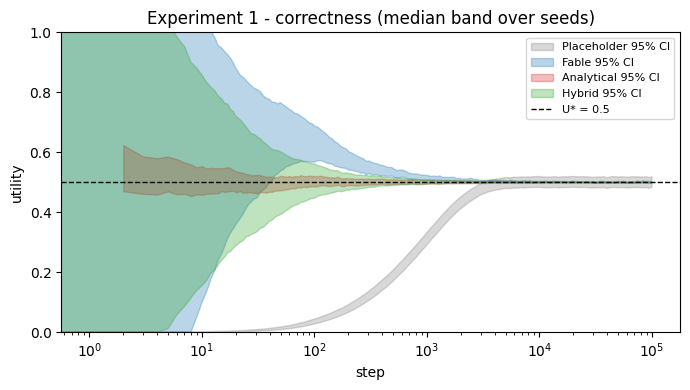

{
  "Placeholder": {
    "coverage": {
      "100": 0.0,
      "1000": 0.0,
      "10000": 1.0,
      "99999": 0.99
    },
    "terminal_width": 0.036002933979034424
  },
  "Fable": {
    "coverage": {
      "100": 0.02,
      "1000": 0.3,
      "10000": 0.08,
      "99999": 0.12
    },
    "terminal_width": 0.002500683069229126
  },
  "Analytical": {
    "coverage": {
      "100": 0.35,
      "1000": 0.48,
      "10000": 0.45,
      "99999": 0.41
    },
    "terminal_width": 0.0023969709873199463
  },
  "Hybrid": {
    "coverage": {
      "100": 0.93,
      "1000": 0.62,
      "10000": 0.47,
      "99999": 0.43
    },
    "terminal_width": 0.002433300018310547
  }
}


In [13]:
T = 100_000
checkpoints = [100, 1_000, 10_000, 100_000]
cfg_py = dict(alpha=ALPHA, sigma=0.1, w_before=1.0, w_after=1.0, onset=0)
cfg = make_config(sigma=cfg_py['sigma'], w=cfg_py['w_after'])
steps = build_log_steps(T, extra=checkpoints)
lcb, ucb = run(cfg, steps, T)
us = u_star(steps, cfg_py)
record_tidy('correctness', 'w=1,sigma=0.1', steps, lcb, ucb, us)

SUMMARY['correctness'] = {}
for mi, (name, _) in enumerate(ESTIMATORS):
    lo, hi = median_band(lcb, ucb, mi)
    SUMMARY['correctness'][name] = dict(coverage=coverage_at(lcb, ucb, us, steps, checkpoints, mi),
                                        terminal_width=float(hi[-1] - lo[-1]))

plt.figure(figsize=(7, 4))
for mi, (name, _) in enumerate(ESTIMATORS):
    lo, hi = median_band(lcb, ucb, mi)
    plt.fill_between(steps, lo, hi, color=METHOD_COLORS[name], alpha=0.30, label=f'{name} 95% CI')
plt.axhline(0.5, color='black', ls='--', lw=1.0, label='U* = 0.5')
plt.xscale('log'); plt.xlabel('step'); plt.ylabel('utility'); plt.ylim(0, 1.0)
plt.title('Experiment 1 - correctness (median band over seeds)')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(OUT_DIR / 'correctness.png', dpi=130); plt.savefig(OUT_DIR / 'correctness.pdf')
plt.show()
print(json.dumps(SUMMARY['correctness'], indent=2))

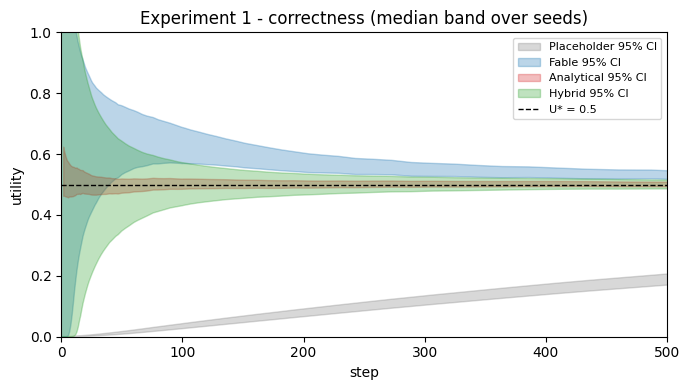

{
  "Placeholder": {
    "coverage": {
      "100": 0.0,
      "1000": 0.0,
      "10000": 1.0,
      "99999": 0.99
    },
    "terminal_width": 0.036002933979034424
  },
  "Fable": {
    "coverage": {
      "100": 0.02,
      "1000": 0.3,
      "10000": 0.08,
      "99999": 0.12
    },
    "terminal_width": 0.002500683069229126
  },
  "Analytical": {
    "coverage": {
      "100": 0.35,
      "1000": 0.48,
      "10000": 0.45,
      "99999": 0.41
    },
    "terminal_width": 0.0023969709873199463
  },
  "Hybrid": {
    "coverage": {
      "100": 0.98,
      "1000": 0.65,
      "10000": 0.48,
      "99999": 0.43
    },
    "terminal_width": 0.002484917640686035
  }
}


In [6]:

plt.figure(figsize=(7, 4))
for mi, (name, _) in enumerate(ESTIMATORS):
    lo, hi = mean_band(lcb, ucb, mi)
    plt.fill_between(steps, lo, hi, color=METHOD_COLORS[name], alpha=0.30, label=f'{name} 95% CI')
plt.axhline(0.5, color='black', ls='--', lw=1.0, label='U* = 0.5')
plt.xlabel('step'); plt.ylabel('utility'); plt.ylim(0.0, 1.0)
plt.xlim(0, 500)
plt.title('Experiment 1 - correctness (median band over seeds)')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(OUT_DIR / 'correctness.png', dpi=130); plt.savefig(OUT_DIR / 'correctness.pdf')
plt.show()
print(json.dumps(SUMMARY['correctness'], indent=2))

## Experiment 2 — Noise sensitivity

More noise makes the bounds take longer to tighten, but they aim at the same `U* = 0.5`.
`w = 1`, `sigma in {0.05, 0.1, 0.2}`, `T = 100k`. Metric: time to reach relative width 0.2 should
increase with `sigma`. (The placeholder bounds the realized contribution, whose spread is
noise-independent, so only a residual-based method like Fable shows this clearly.)

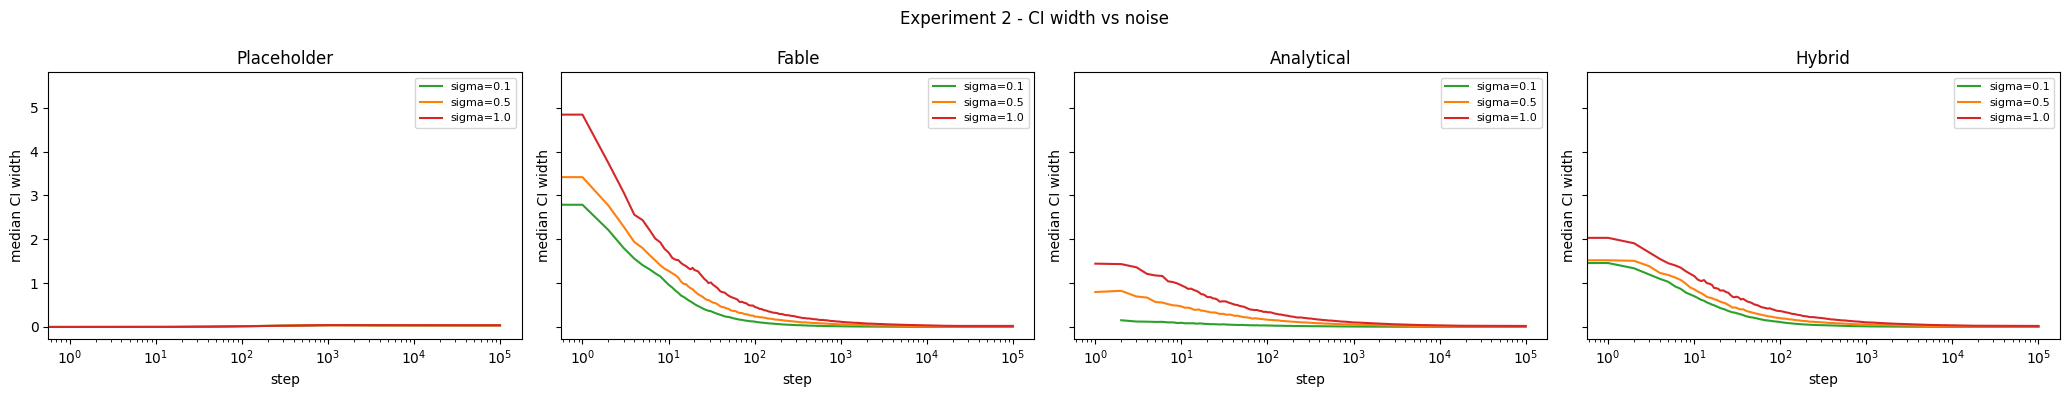

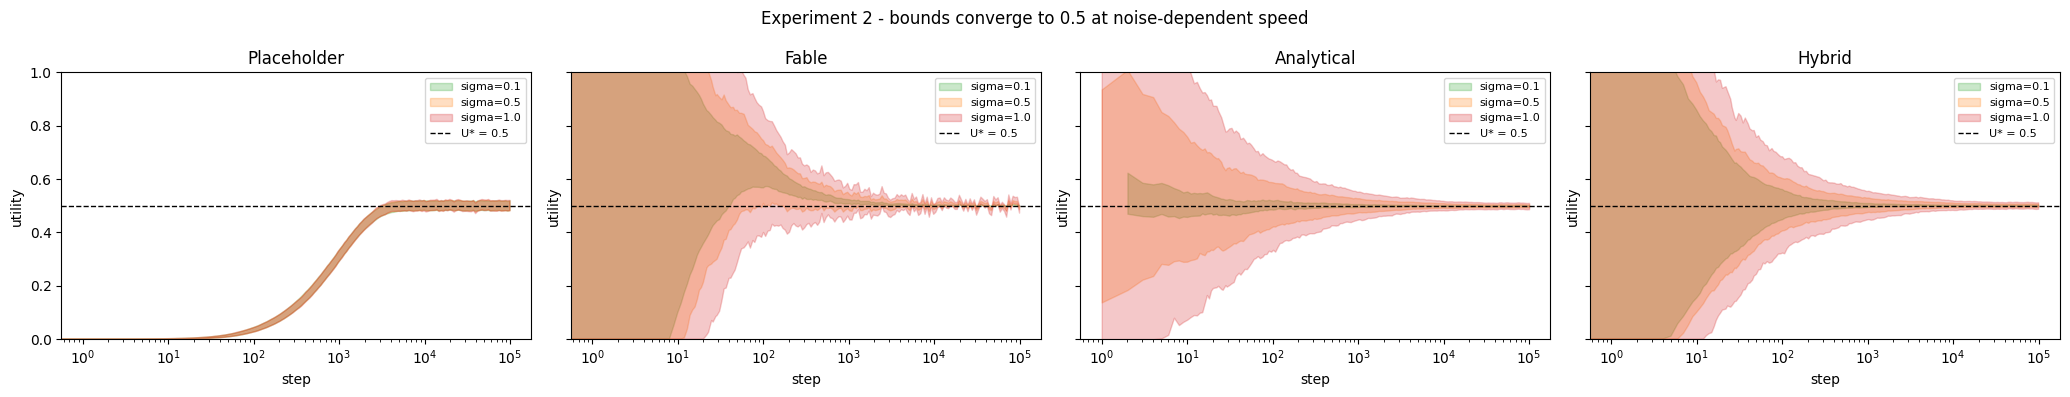

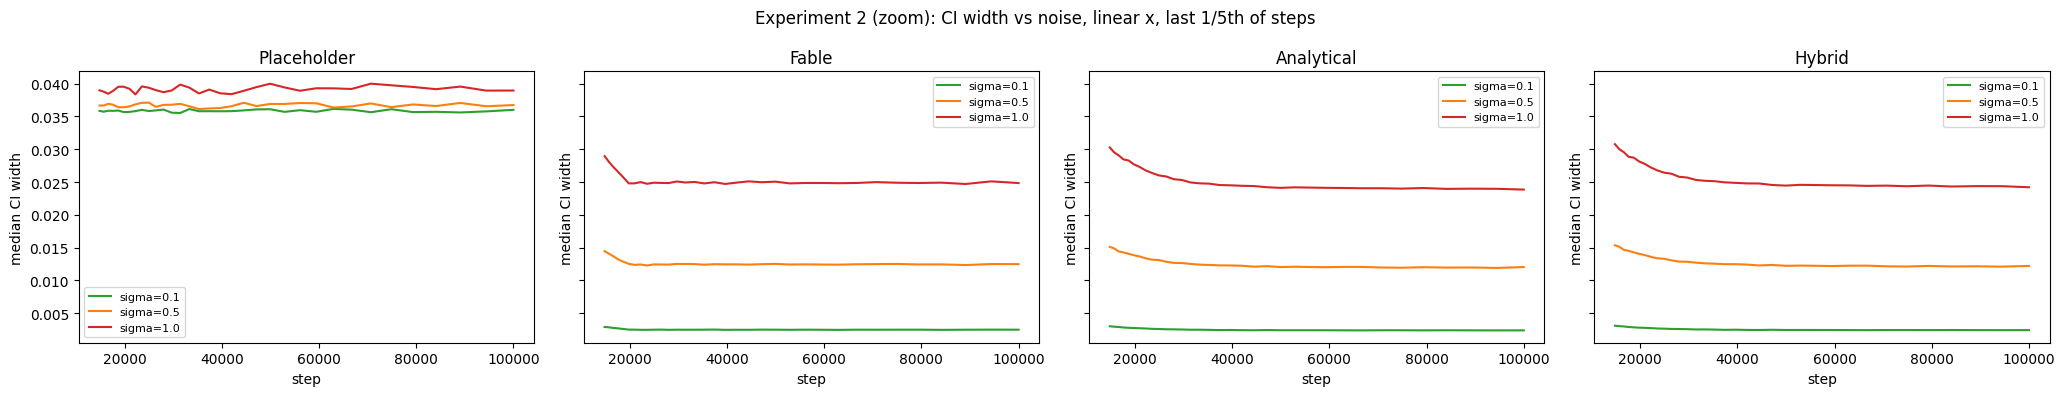

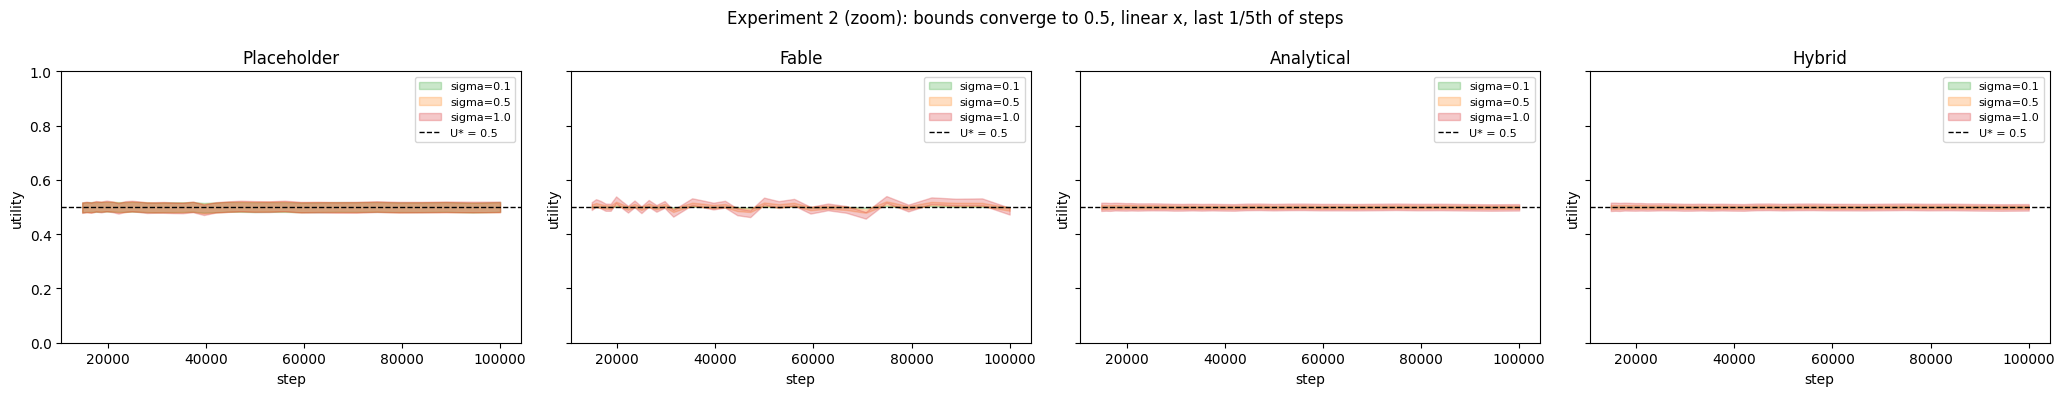

{
  "Placeholder": {
    "sigma=0.1": {
      "steps_to_rel_width_0.2": 0,
      "terminal_estimate": 0.5005207061767578
    },
    "sigma=0.5": {
      "steps_to_rel_width_0.2": 0,
      "terminal_estimate": 0.49925723671913147
    },
    "sigma=1.0": {
      "steps_to_rel_width_0.2": 0,
      "terminal_estimate": 0.5006046295166016
    }
  },
  "Fable": {
    "sigma=0.1": {
      "steps_to_rel_width_0.2": 121,
      "terminal_estimate": 0.499144971370697
    },
    "sigma=0.5": {
      "steps_to_rel_width_0.2": 460,
      "terminal_estimate": 0.4924437999725342
    },
    "sigma=1.0": {
      "steps_to_rel_width_0.2": 1382,
      "terminal_estimate": 0.48469579219818115
    }
  },
  "Analytical": {
    "sigma=0.1": {
      "steps_to_rel_width_0.2": 9,
      "terminal_estimate": 0.49993354082107544
    },
    "sigma=0.5": {
      "steps_to_rel_width_0.2": 306,
      "terminal_estimate": 0.4995269179344177
    },
    "sigma=1.0": {
      "steps_to_rel_width_0.2": 1161,
      "terminal_

In [14]:
T = 100_000
sigmas = [0.1, 0.5, 1.0]
steps = build_log_steps(T)
exp2 = {}
for sigma in sigmas:
    cfg_py = dict(alpha=ALPHA, sigma=sigma, w_before=1.0, w_after=1.0, onset=0)
    cfg = make_config(sigma=sigma, w=1.0)
    lcb, ucb = run(cfg, steps, T)
    record_tidy('noise', f'sigma={sigma}', steps, lcb, ucb, u_star(steps, cfg_py))
    exp2[sigma] = (lcb, ucb)

SUMMARY['noise'] = {}
for mi, (name, _) in enumerate(ESTIMATORS):
    SUMMARY['noise'][name] = {}
    for sigma in sigmas:
        lo, hi = median_band(*exp2[sigma], mi)
        width = hi - lo
        SUMMARY['noise'][name][f'sigma={sigma}'] = {
            'steps_to_rel_width_0.2': first_step_where(width <= 0.2 * 0.5, steps),
            'terminal_estimate': float((lo[-1] + hi[-1]) / 2)}

cmap = {0.1: 'tab:green', 0.5: 'tab:orange', 1.0: 'tab:red'}
n_estimators = len(ESTIMATORS)

# ---- Full plots

figA, axesA = plt.subplots(1, n_estimators, figsize=(5.2 * n_estimators, 4), sharey=True)
for ax, (mi, (name, _)) in zip(np.atleast_1d(axesA).ravel(), enumerate(ESTIMATORS)):
    for sigma in sigmas:
        lo, hi = median_band(*exp2[sigma], mi)
        ax.plot(steps, hi - lo, color=cmap[sigma], label=f'sigma={sigma}')
    ax.set_xscale('log'); ax.set_title(name); ax.set_xlabel('step'); ax.set_ylabel('median CI width')
    ax.legend(fontsize=8)
figA.suptitle('Experiment 2 - CI width vs noise'); figA.tight_layout()
figA.savefig(OUT_DIR / 'noise_width.png', dpi=130)
figA.savefig(OUT_DIR / 'noise_width.pdf')
plt.show()

figB, axesB = plt.subplots(1, n_estimators, figsize=(5.2 * n_estimators, 4), sharey=True)
for ax, (mi, (name, _)) in zip(np.atleast_1d(axesB).ravel(), enumerate(ESTIMATORS)):
    for sigma in sigmas:
        lo, hi = median_band(*exp2[sigma], mi)
        ax.fill_between(steps, lo, hi, color=cmap[sigma], alpha=0.25, label=f'sigma={sigma}')
    ax.axhline(0.5, color='black', ls='--', lw=1.0, label='U* = 0.5')
    ax.set_xscale('log'); ax.set_ylim(0, 1.0); ax.set_title(name)
    ax.set_xlabel('step'); ax.set_ylabel('utility'); ax.legend(fontsize=8)
figB.suptitle('Experiment 2 - bounds converge to 0.5 at noise-dependent speed'); figB.tight_layout()
figB.savefig(OUT_DIR / 'noise_bounds.png', dpi=130)
figB.savefig(OUT_DIR / 'noise_bounds.pdf')
plt.show()

# ---- Zoomed-in plots (last 1/5th of timesteps, linear scale)

if len(steps) > 1:
    idx_zoom = int(len(steps) * 0.8)  # Start at 80% to end (last 1/5th)
    steps_zoom = steps[idx_zoom:]

    # CI width zoomed
    figA_zoom, axesA_zoom = plt.subplots(1, n_estimators, figsize=(5.2 * n_estimators, 4), sharey=True)
    for ax, (mi, (name, _)) in zip(np.atleast_1d(axesA_zoom).ravel(), enumerate(ESTIMATORS)):
        for sigma in sigmas:
            lo, hi = median_band(*exp2[sigma], mi)
            ax.plot(steps_zoom, (hi - lo)[idx_zoom:], color=cmap[sigma], label=f'sigma={sigma}')
        ax.set_xscale('linear')
        ax.set_title(name)
        ax.set_xlabel('step')
        ax.set_ylabel('median CI width')
        ax.legend(fontsize=8)
    figA_zoom.suptitle('Experiment 2 (zoom): CI width vs noise, linear x, last 1/5th of steps')
    figA_zoom.tight_layout()
    figA_zoom.savefig(OUT_DIR / 'noise_width_zoom.png', dpi=130)
    figA_zoom.savefig(OUT_DIR / 'noise_width_zoom.pdf')
    plt.show()

    # Bounds zoomed
    figB_zoom, axesB_zoom = plt.subplots(1, n_estimators, figsize=(5.2 * n_estimators, 4), sharey=True)
    for ax, (mi, (name, _)) in zip(np.atleast_1d(axesB_zoom).ravel(), enumerate(ESTIMATORS)):
        for sigma in sigmas:
            lo, hi = median_band(*exp2[sigma], mi)
            ax.fill_between(steps_zoom, lo[idx_zoom:], hi[idx_zoom:], color=cmap[sigma], alpha=0.25, label=f'sigma={sigma}')
        ax.axhline(0.5, color='black', ls='--', lw=1.0, label='U* = 0.5')
        ax.set_xscale('linear')
        ax.set_ylim(0, 1.0)
        ax.set_title(name)
        ax.set_xlabel('step')
        ax.set_ylabel('utility')
        ax.legend(fontsize=8)
    figB_zoom.suptitle('Experiment 2 (zoom): bounds converge to 0.5, linear x, last 1/5th of steps')
    figB_zoom.tight_layout()
    figB_zoom.savefig(OUT_DIR / 'noise_bounds_zoom.png', dpi=130)
    figB_zoom.savefig(OUT_DIR / 'noise_bounds_zoom.pdf')
    plt.show()

print(json.dumps(SUMMARY['noise'], indent=2))

## Experiment 3 — Granularity

Shrink the signal and the method still figures out the feature is useful, just later.
`sigma = 0.1`, `w in {1, 0.1, 0.01}`, `T = 1M`, so `U* in {0.5, 0.05, 0.005}`. Metric: time for the
median LCB to clear a small floor `tau = 1e-4`. Detection cost grows like `(sigma/w)^2`, so the
smallest signal may resolve late or not at all within budget - a valid characterization of the floor.

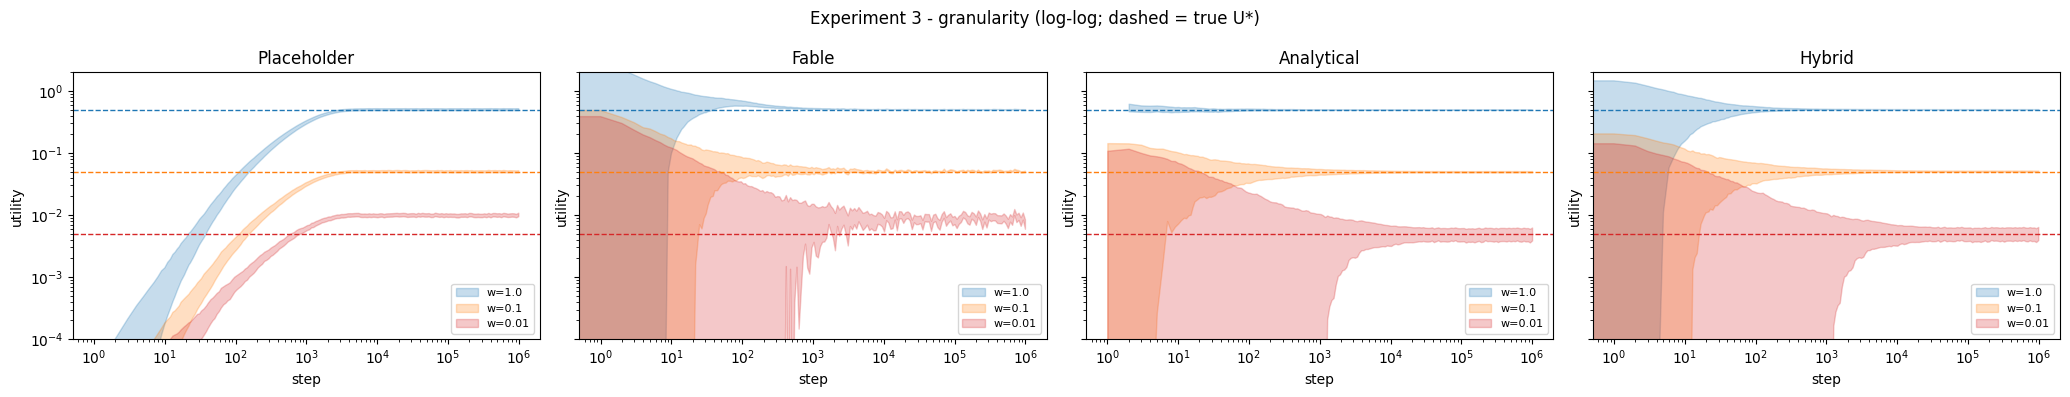

{
  "Placeholder": {
    "w=1.0": {
      "time_lcb_above_floor": 9,
      "terminal_lo": 0.4826326370239258,
      "terminal_hi": 0.5183757543563843,
      "u_star": 0.5
    },
    "w=0.1": {
      "time_lcb_above_floor": 19,
      "terminal_lo": 0.04801297187805176,
      "terminal_hi": 0.05199859291315079,
      "u_star": 0.05
    },
    "w=0.01": {
      "time_lcb_above_floor": 36,
      "terminal_lo": 0.009403328411281109,
      "terminal_hi": 0.010726477950811386,
      "u_star": 0.005
    }
  },
  "Fable": {
    "w=1.0": {
      "time_lcb_above_floor": 9,
      "terminal_lo": 0.4979214668273926,
      "terminal_hi": 0.5004050731658936,
      "u_star": 0.5
    },
    "w=0.1": {
      "time_lcb_above_floor": 22,
      "terminal_lo": 0.048485420644283295,
      "terminal_hi": 0.05097014084458351,
      "u_star": 0.05
    },
    "w=0.01": {
      "time_lcb_above_floor": 419,
      "terminal_lo": 0.005901291035115719,
      "terminal_hi": 0.008388791233301163,
      "u_star": 0.005
 

In [15]:
T = 1_000_000
ws = [1.0, 0.1, 0.01]
tau = 1e-4
steps = build_log_steps(T)
exp3 = {}
for w in ws:
    cfg_py = dict(alpha=ALPHA, sigma=0.1, w_before=w, w_after=w, onset=0)
    cfg = make_config(sigma=0.1, w=w)
    lcb, ucb = run(cfg, steps, T)
    record_tidy('granularity', f'w={w}', steps, lcb, ucb, u_star(steps, cfg_py))
    exp3[w] = (lcb, ucb)

SUMMARY['granularity'] = {}
for mi, (name, _) in enumerate(ESTIMATORS):
    SUMMARY['granularity'][name] = {}
    for w in ws:
        lo, hi = median_band(*exp3[w], mi)
        SUMMARY['granularity'][name][f'w={w}'] = dict(
            time_lcb_above_floor=first_step_where(lo > tau, steps),
            terminal_lo=float(lo[-1]), terminal_hi=float(hi[-1]), u_star=float(abs(w) * EX_ABS))

cmap3 = {1.0: 'tab:blue', 0.1: 'tab:orange', 0.01: 'tab:red'}
fig, axes = plt.subplots(1, len(ESTIMATORS), figsize=(5.2 * len(ESTIMATORS), 4), sharey=True)
for ax, (mi, (name, _)) in zip(np.atleast_1d(axes).ravel(), enumerate(ESTIMATORS)):
    for w in ws:
        lo, hi = median_band(*exp3[w], mi)
        ax.fill_between(steps, np.maximum(lo, 1e-6), np.maximum(hi, 1e-6),
                        color=cmap3[w], alpha=0.25, label=f'w={w}')
        ax.axhline(abs(w) * EX_ABS, color=cmap3[w], ls='--', lw=1.0)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-4, 2.0)
    ax.set_title(name); ax.set_xlabel('step'); ax.set_ylabel('utility'); ax.legend(fontsize=8)
fig.suptitle('Experiment 3 - granularity (log-log; dashed = true U*)'); fig.tight_layout()
fig.savefig(OUT_DIR / 'granularity.png', dpi=130); fig.savefig(OUT_DIR / 'granularity.pdf'); plt.show()
print(json.dumps(SUMMARY['granularity'], indent=2))

## Experiment 4 — Tracking a rising utility

The bounds stay low while there is nothing to find, then climb to the true value once the signal
appears. `w = 1`, `sigma = 0.1`, `T = 150k`, onset at `t = 50k` (`U*` jumps 0 -> 0.5). Dense logging
around the onset. Tests *tracking* an externally imposed rise, not anticipating an endogenous one.

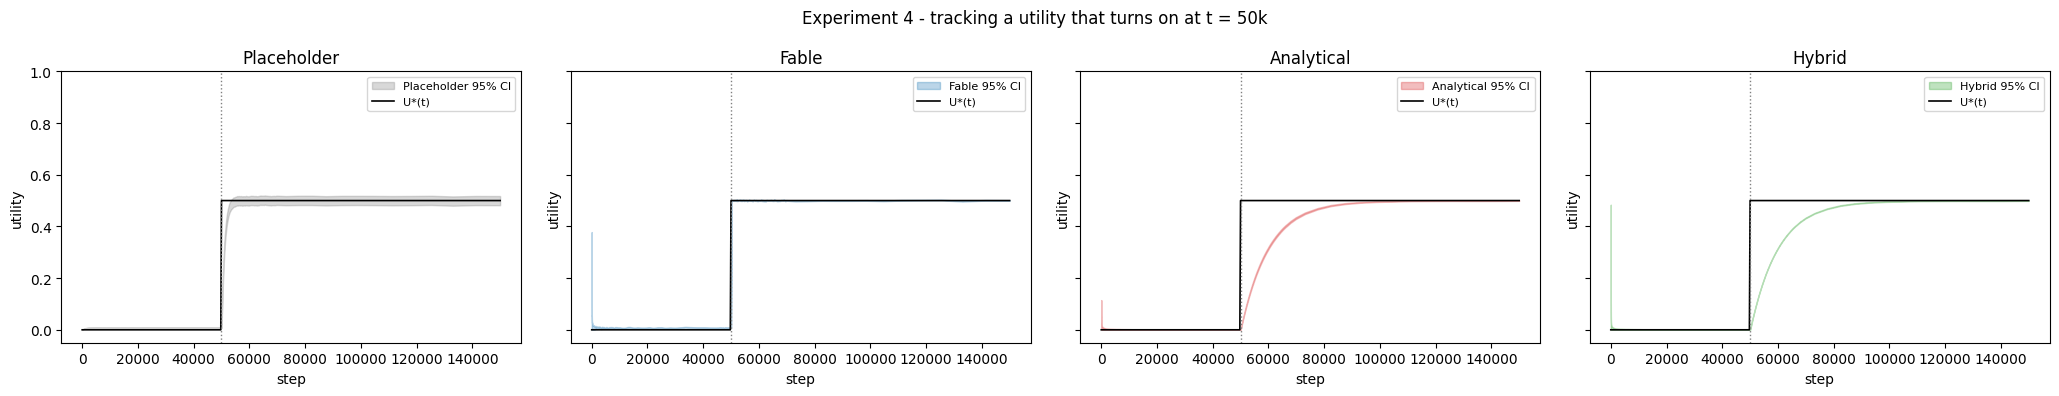

{
  "Placeholder": {
    "ucb_just_before_onset": 0.009641408920288086,
    "recovery_step": 53500,
    "bracketed_at_end": true,
    "coverage": {
      "10129": 0.0,
      "40165": 0.0,
      "60000": 1.0,
      "98631": 1.0,
      "149999": 1.0
    }
  },
  "Fable": {
    "ucb_just_before_onset": 0.009207510389387608,
    "recovery_step": 50250,
    "bracketed_at_end": true,
    "coverage": {
      "10129": 0.11,
      "40165": 0.08,
      "60000": 0.17,
      "98631": 0.14,
      "149999": 0.07
    }
  },
  "Analytical": {
    "ucb_just_before_onset": 0.0016723547596484423,
    "recovery_step": 111182,
    "bracketed_at_end": true,
    "coverage": {
      "10129": 0.95,
      "40165": 0.96,
      "60000": 0.0,
      "98631": 0.06,
      "149999": 0.46
    }
  },
  "Hybrid": {
    "ucb_just_before_onset": 0.0017177151748910546,
    "recovery_step": 111182,
    "bracketed_at_end": true,
    "coverage": {
      "10129": 0.96,
      "40165": 0.96,
      "60000": 0.0,
      "98631": 0.0

In [9]:
T = 150_000
T_onset = 50_000
dense = np.arange(T_onset - 5_000, T_onset + 20_000, 250)
steps = build_log_steps(T, extra=dense)
cfg_py = dict(alpha=ALPHA, sigma=0.1, w_before=0.0, w_after=1.0, onset=T_onset)
cfg = make_config(sigma=0.1, w=1.0, onset=T_onset, w_before=0.0)
lcb, ucb = run(cfg, steps, T)
us = u_star(steps, cfg_py)
record_tidy('onset', 'w:0->1 at 50k', steps, lcb, ucb, us)

SUMMARY['onset'] = {}
checkpoints = [10_000, 40_000, 60_000, 100_000, 149_000]
pre_idx = np.where(steps < T_onset)[0]
post_idx = np.where(steps >= T_onset)[0]
for mi, (name, _) in enumerate(ESTIMATORS):
    lo, hi = median_band(lcb, ucb, mi)
    brackets = (lo <= 0.5) & (0.5 <= hi)
    rec_hits = post_idx[brackets[post_idx]]            # post-onset steps where the median band holds 0.5
    SUMMARY['onset'][name] = dict(
        ucb_just_before_onset=float(hi[pre_idx[-1]]),  # should sit near 0 (signal still off)
        recovery_step=int(steps[rec_hits[0]]) if rec_hits.size else None,
        bracketed_at_end=bool(brackets[-1]),
        coverage=coverage_at(lcb, ucb, us, steps, checkpoints, mi))

fig, axes = plt.subplots(1, len(ESTIMATORS), figsize=(5.2 * len(ESTIMATORS), 4), sharey=True)
for ax, (mi, (name, _)) in zip(np.atleast_1d(axes).ravel(), enumerate(ESTIMATORS)):
    lo, hi = median_band(lcb, ucb, mi)
    ax.fill_between(steps, lo, hi, color=METHOD_COLORS[name], alpha=0.30, label=f'{name} 95% CI')
    ax.plot(steps, us, color='black', lw=1.2, label='U*(t)')
    ax.axvline(T_onset, color='gray', ls=':', lw=1.0)
    ax.set_title(name); ax.set_xlabel('step'); ax.set_ylabel('utility'); ax.set_ylim(-0.05, 1.0)
    ax.legend(fontsize=8)
fig.suptitle('Experiment 4 - tracking a utility that turns on at t = 50k'); fig.tight_layout()
fig.savefig(OUT_DIR / 'onset.png', dpi=130); fig.savefig(OUT_DIR / 'onset.pdf'); plt.show()
print(json.dumps(SUMMARY['onset'], indent=2))

## Outputs

Write the tidy long-format log (`experiment, condition, method, seed, step, lcb, ucb, u_star`),
the metrics `summary.json`, and the plots (already saved as `.png` + `.pdf`) under `data/ci_suite/`.

In [10]:
tidy = pd.DataFrame(TIDY_ROWS, columns=['experiment', 'condition', 'method', 'seed', 'step',
                                        'lcb', 'ucb', 'u_star'])
tidy.to_csv(OUT_DIR / 'records.csv', index=False)
with open(OUT_DIR / 'summary.json', 'w') as f:
    json.dump(SUMMARY, f, indent=2)
print(f'wrote {len(tidy)} rows to {OUT_DIR / "records.csv"}')
print('plots + summary.json in', OUT_DIR.resolve())
print(json.dumps(SUMMARY, indent=2))

wrote 586000 rows to data/ci_suite/records.csv
plots + summary.json in /home/edan/local_projects/phd_research/phd/sandbox/feature_sifting/data/ci_suite
{
  "correctness": {
    "Placeholder": {
      "coverage": {
        "100": 0.0,
        "1000": 0.0,
        "10000": 1.0,
        "99999": 0.99
      },
      "terminal_width": 0.036002933979034424
    },
    "Fable": {
      "coverage": {
        "100": 0.02,
        "1000": 0.3,
        "10000": 0.08,
        "99999": 0.12
      },
      "terminal_width": 0.002500683069229126
    },
    "Analytical": {
      "coverage": {
        "100": 0.35,
        "1000": 0.48,
        "10000": 0.45,
        "99999": 0.41
      },
      "terminal_width": 0.0023969709873199463
    },
    "Hybrid": {
      "coverage": {
        "100": 0.98,
        "1000": 0.65,
        "10000": 0.48,
        "99999": 0.43
      },
      "terminal_width": 0.002484917640686035
    }
  },
  "noise": {
    "Placeholder": {
      "sigma=0.1": {
        "steps_to_rel_w